# 11.4.1 从单体相位到群体指标

## 学习目标与先修知识

实现耦合相位（phase）模型（model）并分辨全局相位一致与分群。

先修：4.2 振荡与相位；11.1 网络邻接；复数（complex number）极坐标只需本节给出的含义。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

四个细胞节律相位分别为 0、0、π、π：每组内部完全一致，但合起来两组相反。怎样用一个全局数值描述相位聚集，又避免把全局抵消误称为“没有任何同步”？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先把相位当作单位圆上的箭头：两个指右、两个指左，平均向量（vector）的长度为0。

In [2]:
print('相位[0,0,π,π]的向量和：(1+1−1−1, 0)= (0,0)。')

相位[0,0,π,π]的向量和：(1+1−1−1, 0)= (0,0)。


## 模型假设

相位以 rad 计，$e^{i\theta}$ 是平面单位箭头。单体未耦合时 $\dot\theta_i=\omega_i$；有耦合时仅沿无向边加 $\sin(\theta_j-\theta_i)$，并按节点度归一化耦合总尺度。模型不表示细胞节律的全部机制。

## 数学解释与推导

全局序参量（order parameter）$R=\left|n^{-1}\sum_j e^{i\theta_j}\right|$，满足 $0\le R\le1$。所有相位相同时 $R=1$；共同加 $\phi$ 只会让平均复向量乘 $e^{i\phi}$，模不变。两组反相可能 $R=0$，但组内仍一致，故还需观察分群或边上相位差。网络相位方程为 $\dot\theta_i=\omega_i+K\sum_j A_{ij}\sin(\theta_j-\theta_i)/\max(1,d_i)$。$R$ 描述同一时刻的相位集中，不证明长期平均频率锁定（frequency locking）。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def order_parameter(phases):
    import numpy as np
    return float(abs(np.exp(1j * np.asarray(phases, dtype=float)).mean()))


def phase_step(phases, frequencies, edges, coupling, dt):
    """One explicit network phase step; coupling normalized by node degree."""
    import math
    n = len(phases)
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    return [phases[i] + dt * (frequencies[i] + coupling / max(1, degree[i]) *
                             sum(a[i][j] * math.sin(phases[j] - phases[i]) for j in range(n)))
            for i in range(n)]


def phase_run(phases, frequencies, edges, coupling, dt, steps):
    current = list(phases)
    history = [current.copy()]
    for _ in range(steps):
        current = phase_step(current, frequencies, edges, coupling, dt)
        history.append(current)
    return history, [order_parameter(row) for row in history]

## 对照实验

比较全同相、两组反相和在四节点环上耦合演化；左图显示单位圆箭头端点，右图显示 R 随时间变化。

全同相R= 1.0 反相两组R= 6.123233995736766e-17


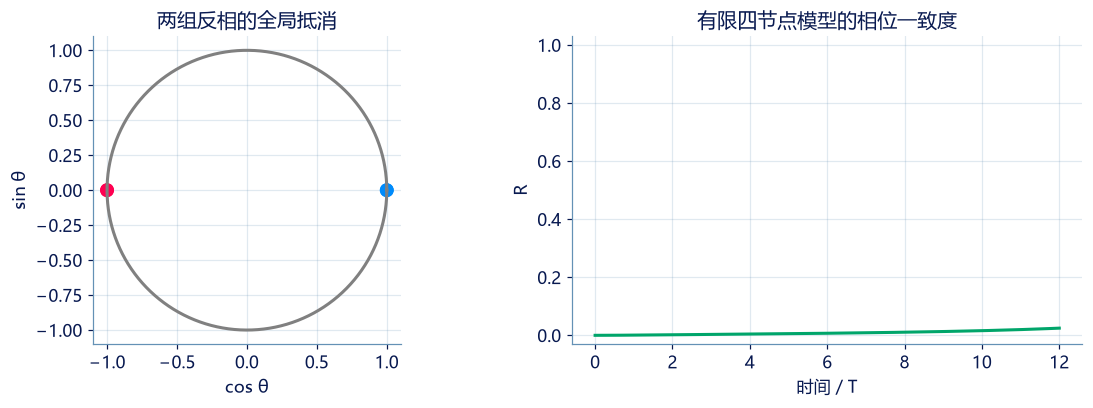

In [4]:
phases=[0.,0.,math.pi,math.pi]
print('全同相R=',order_parameter([0.]*4),'反相两组R=',order_parameter(phases))
edge_ring=[[0,1],[1,2],[2,3],[3,0]]
history,order=phase_run(phases,[1.,1.05,.95,1.1],edge_ring,1.2,.02,600)
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
t=np.linspace(0,2*math.pi,300);axes[0].plot(np.cos(t),np.sin(t),color='gray')
axes[0].scatter(np.cos(phases),np.sin(phases),s=65,color=[BLUE,BLUE,PINK,PINK])
axes[0].set(aspect='equal',xlabel='cos θ',ylabel='sin θ',title='两组反相的全局抵消')
axes[1].plot(np.arange(len(order))*.02,order,color=GREEN)
axes[1].set(xlabel='时间 / T',ylabel='R',ylim=(-.03,1.03),title='有限四节点模型的相位一致度');plt.show()

## 结果解释

反相两组的 R 接近0，是全局平均向量相互抵消，并不表示组内没有相位一致性或局部同步结构。右图只对应所选网络、频率和初相；它本身没有展示长期频率锁定。

### 独立核对

检验共同平移不变、边界 $0\le R\le1$ 与零耦合时单体相位线性增长。

In [5]:
for shift in [-2.,0.,1.3]:
    np.testing.assert_allclose(order_parameter([x+shift for x in phases]),order_parameter(phases),atol=1e-12)
assert all(-1e-12<=x<=1+1e-12 for x in order)
no_coupling,_=phase_run([0.,.1],[1.,2.],[[0,1]],0.,.1,10)
np.testing.assert_allclose(no_coupling[-1],[1.,2.1],atol=1e-12)
print('相位平移、指标边界与零耦合解析结果一致。')

相位平移、指标边界与零耦合解析结果一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算全局相位序参量

给出同一时刻 n 个相位（phase）（弧度），计算 R=|n⁻¹∑ exp(iθ_j)|。不要把相位先做普通算术平均；R 应在[0,1]。

**函数与代码模板**

```python
def solve(
    phases: list[float],
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `phases` | `list[float]` | 非空相位列表。 | rad |

**返回值**

直接返回 R（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `R` | `float` | 全局相位一致程度。 | 1 |

**计算规则**

分别平均 cosθ 与 sinθ，再取向量（vector）长度；所有相位共同平移不改变 R。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| phases | 非空相位列表。 | [0.0, 0.0, 0.0] | rad |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
phases = [0.0, 0.0, 0.0]

result = solve(phases)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| R | 全局相位一致程度。 | 1 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 1.0
```

**样例解释**

三个相位完全相同，三个单位复向量方向一致，因此平均向量模长（modulus）为1。作为对照，两组等人数反相时向量可以相互抵消，使 R≈0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算全局相位序参量](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-phase-order-parameter)

### 第 2 题 · 单项选择题：共同平移全部相位

全部相位（phase）加同一个常数 φ，R 会怎样？

- **A.** 保持不变，因为平均复相位只整体旋转。
- **B.** 必加上 φ。
- **C.** 只在 φ=0 时不变。
- **D.** 变成平均频率。

[作答：共同平移全部相位](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-phase-shift-invariance)

### 第 3 题 · 单项选择题：全局 R 小也可能有结构

四个相位（phase）为[0,0,π,π]。哪项描述最准确？

- **A.** 全局R≈0，但存在两组组内相位一致。
- **B.** R≈1，所有相位完全相同。
- **C.** 没有任何成对相位关系。
- **D.** 仅凭这一时刻就可证明频率锁定（frequency locking）。

[作答：全局 R 小也可能有结构](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-antiphase-clusters)

### 第 4 题 · 单项选择题：相位靠近与频率锁定

单时刻 R=0.95。能否证明各振子长期平均频率相同？

- **A.** 能，R 足够大。
- **B.** 不能；R 是瞬时相位（phase）指标，还需检查时间窗内的相位漂移或平均频率。
- **C.** 能，因为固有频率必相同。
- **D.** 不能测量 R，因为相位有弧度单位。

[作答：相位靠近与频率锁定](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-phase-vs-frequency)

**进一步阅读**

[Kuramoto 与 Battogtokh 的原始研究预印本](https://arxiv.org/abs/cond-mat/0210694)展示相位振子的空间依赖序参量。